In [2]:
%run NewChartsCommon.ipynb
import pandas as pd


df_algorithms = pd.read_csv("all_algo_makespans.csv")
print(df_algorithms.columns)


path = "./output-autochoice/merged/*.txt"
print(path)

print("\n-----------------\n autochoice - with parameters \n ")
patterndevs = r'^(autochoice)-(with-params)'

dfs=read_dfs(path,patterndevs, 2)
dfautochoice = list(dfs.values())[0]
#dfautochoice['wf_name'] = dfautochoice['wf_name'].map(lambda x: x.rstrip('.dot'))

print(dfautochoice.columns)

Index(['wf_name', 'inp_size', 'ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2',
       'ms_1_A3', 'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5',
       'size', 'deviations'],
      dtype='object')
./output-autochoice/merged/*.txt

-----------------
 autochoice - with parameters 
 
Index(['algo_nr', 'wf_name', 'inp_size', 'chainProb', 'hubScore', 'bypBra',
       'maxIndSetR', 'cpRat', 'wSkew', 'memToComp', 'memToIo', 'auto-num',
       'auto-name', 'Unnamed: 13'],
      dtype='object')


In [3]:
df_master = pd.merge(df_algorithms, dfautochoice, on=['wf_name', 'inp_size'], how='left')
print(df_master.head())
print(df_master.columns)

               wf_name     inp_size       ms_1_A1       ms_2_A1       ms_1_A2  \
0    atacseq_30000.dot  14091675276  1.596304e+09  1.754081e+09  1.594847e+09   
1    chipseq_15000.dot  41366257414  2.464778e+09  2.824716e+09  2.464349e+09   
2  methylseq_15000.dot   6761426956  5.680249e+08  5.689832e+08  5.680249e+08   
3    atacseq_15000.dot   3908761308  2.580841e+08  3.216120e+08  2.548479e+08   
4                eager  19075314980  2.206378e+06  2.137663e+06  1.750158e+06   

        ms_2_A2       ms_1_A3       ms_2_A3       ms_1_A4       ms_2_A4  ...  \
0  2.152673e+09  1.595243e+09  3.592100e+08  1.595155e+09  7.630277e+08  ...   
1  2.823101e+09  2.454982e+09  1.204541e+09  2.465649e+09  1.442950e+09  ...   
2  5.689833e+08  5.680249e+08  7.483464e+08  5.680249e+08  5.689840e+08  ...   
3  3.413491e+08  2.571888e+08  1.901722e+08  2.580213e+08  2.110520e+08  ...   
4  1.699886e+06  1.686503e+06  1.591133e+06  9.126907e+05  1.808937e+06  ...   

    hubScore  bypBra  maxIndSetR

In [4]:
alg_columns = ['ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2', 'ms_1_A3', 
               'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5']

# Map the column names to your pretty names
friendly_names = {
    'ms_1_A1': 'Online MeDiH-BL', 'ms_2_A1': 'Offline MeDiH-BL',
    'ms_1_A2': 'Online MeDiH-BLC', 'ms_2_A2': 'Offline MeDiH-BLC',
    'ms_1_A3': 'Online MeDiH-MM', 'ms_2_A3': 'Offline MeDiH-MM',
    'ms_1_A4': 'Online MeDiH-I', 'ms_2_A4': 'Offline MeDiH-I',
    'ms_1_A5': 'Online MeDiH-BL-R', 'ms_2_A5': 'Offline MeDiH-BL-R'
}

# Find the column name with the minimum value for each row
df_master['best_alg_column'] = df_master[alg_columns].idxmin(axis=1)

# Convert that to your pretty names for the target label
df_master['target'] = df_master['best_alg_column'].map(friendly_names)
print(df_master)

                     wf_name     inp_size       ms_1_A1       ms_2_A1  \
0          atacseq_30000.dot  14091675276  1.596304e+09  1.754081e+09   
1          chipseq_15000.dot  41366257414  2.464778e+09  2.824716e+09   
2        methylseq_15000.dot   6761426956  5.680249e+08  5.689832e+08   
3          atacseq_15000.dot   3908761308  2.580841e+08  3.216120e+08   
4                      eager  19075314980  2.206378e+06  2.137663e+06   
..                       ...          ...           ...           ...   
800     dag_50_general_3.dot            1  4.140698e+08  5.083846e+08   
801     dag_50_general_1.dot            1  4.387804e+08  5.221145e+08   
802   dag_8000_general_4.dot            1  3.718071e+10  4.452338e+10   
803  dag_10000_general_1.dot            1  4.539889e+10  5.464453e+10   
804        dag_50_wide_1.dot            1  1.874546e+08  2.281694e+08   

          ms_1_A2       ms_2_A2       ms_1_A3       ms_2_A3       ms_1_A4  \
0    1.594847e+09  2.152673e+09  1.595243e+09 

In [5]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Prepare your data
# Features: [width, critical_path, ccr, skew, etc.]
# Target: The name of the best algorithm (e.g., 'A5')
X = df_master[['inp_size', 'chainProb', 'hubScore', 'bypBra',
       'maxIndSetR', 'cpRat', 'wSkew', 'memToComp', 'memToIo','deviations', 'size']] 
y = LabelEncoder().fit_transform(df_master['best_alg_column'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Define & Train
model = xgb.XGBClassifier(objective='multi:softmax', num_class=10)
model.fit(X_train, y_train)

# 3. Test
predictions = model.predict(X_test)

Overall Accuracy: 49.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.58      0.53        26
           1       0.17      0.17      0.17        12
           2       0.52      0.48      0.50        23
           3       0.20      0.15      0.17        13
           4       0.10      0.09      0.10        11
           5       0.31      0.67      0.42         6
           6       0.25      0.25      0.25         4
           7       0.78      0.71      0.75        35
           8       0.78      0.70      0.74        10
           9       0.58      0.52      0.55        21

    accuracy                           0.49       161
   macro avg       0.42      0.43      0.42       161
weighted avg       0.50      0.49      0.49       161



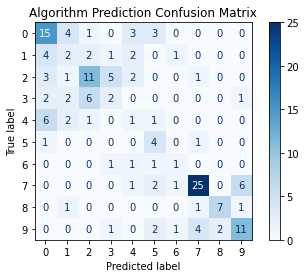

In [6]:
from sklearn.metrics import classification_report, accuracy_score

# Get the accuracy percentage
accuracy = accuracy_score(y_test, predictions)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# See precision/recall for every algorithm variant
print("\nClassification Report:")
print(classification_report(y_test, predictions))


import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Algorithm Prediction Confusion Matrix")
plt.show()

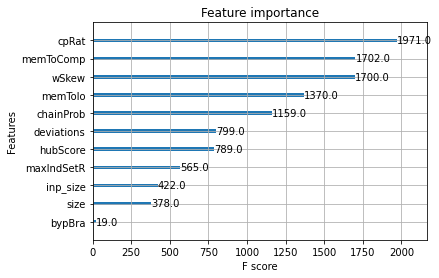

In [26]:
xgb.plot_importance(model)
plt.show()

In [27]:
# 1. Get the original indices of the test set
test_indices = X_test.index

# 2. Get the makespans of the BEST possible algorithms for those rows
# (The 'ground truth' minimums)
optimal_makespans = df_master.loc[test_indices, alg_columns].min(axis=1)

# 3. Get the makespans of the algorithms our AI CHOSE
# First, convert numeric predictions back to column names (e.g., 0 -> 'ms_1_A1')
predicted_alg_cols = [alg_columns[p] for p in predictions]

# Extract the makespan value from the specific column the AI picked for each row
predicted_makespans = [df_master.loc[idx, col] for idx, col in zip(test_indices, predicted_alg_cols)]

# 4. Calculate Regret
# (Predicted - Optimal) / Optimal
regret = (pd.Series(predicted_makespans) - optimal_makespans.values) / optimal_makespans.values

print(f"Mean Relative Regret: {regret.mean() * 100:.2f}%")
print(f"Max Regret (Worst Case): {regret.max() * 100:.2f}%")

worst_idx = test_indices[regret.argmax()]
print(df_master.loc[worst_idx])

Mean Relative Regret: 35.31%
Max Regret (Worst Case): 480.98%
wf_name                    atacseq
inp_size               11809629756
ms_1_A1              376370.932506
ms_2_A1              354657.911238
ms_1_A2              372060.075871
ms_2_A2              357170.488913
ms_1_A3              197890.832196
ms_2_A3              214854.290142
ms_1_A4               61477.397816
ms_2_A4              217144.363409
ms_1_A5              325038.880767
ms_2_A5              304257.750516
size                           100
deviations                    True
algo_nr                          1
chainProb                 0.536585
hubScore                  0.695122
bypBra                           1
maxIndSetR                0.731707
cpRat                    1943580.0
wSkew                      2.13598
memToComp                  375.728
memToIo                   0.782702
auto-num                         6
auto-name          Online_MeDiH-BL
Unnamed: 13                    NaN
best_alg_column            m

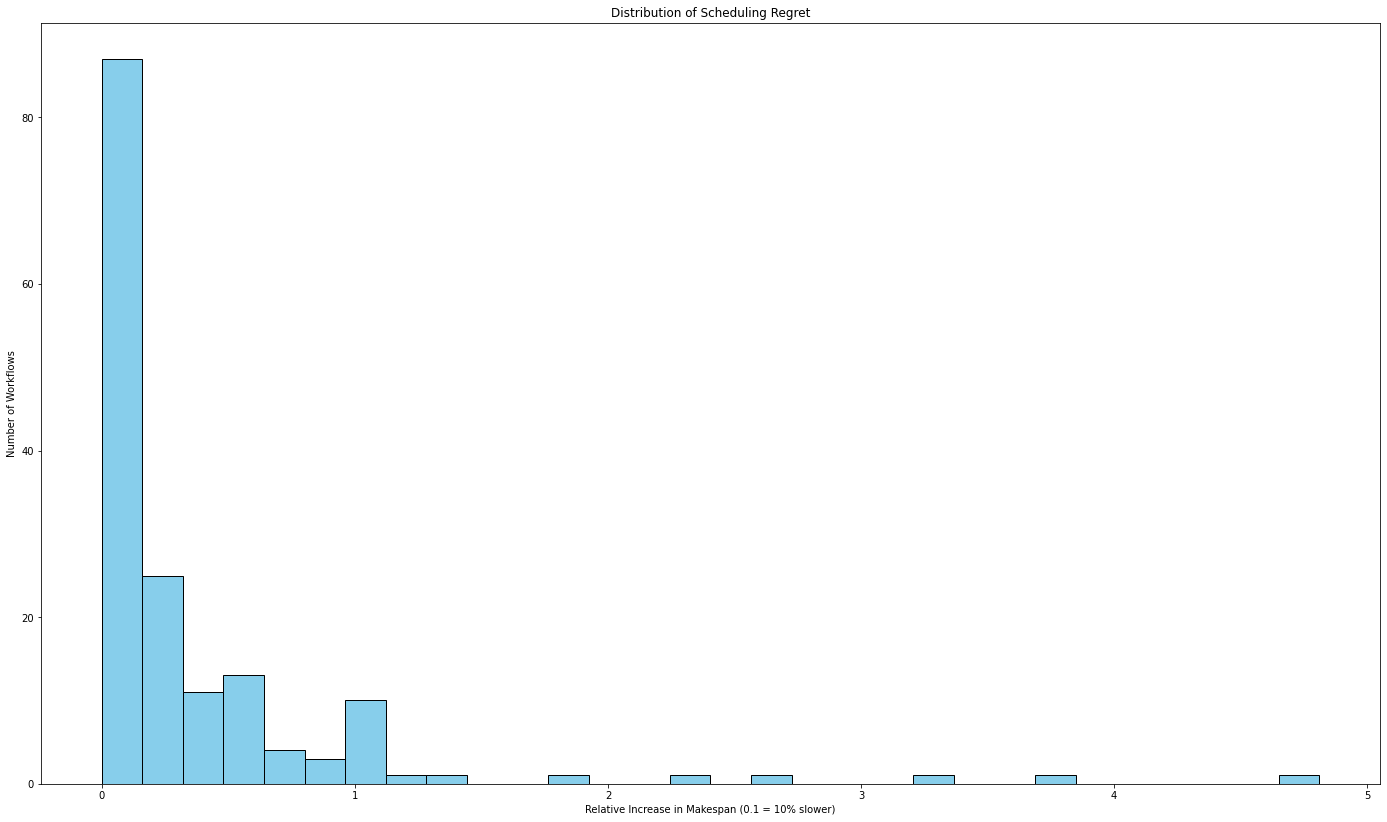

In [28]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(24, 14))
plt.hist(regret, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Scheduling Regret")
plt.xlabel("Relative Increase in Makespan (0.1 = 10% slower)")
plt.ylabel("Number of Workflows")
plt.show()

In [47]:


import numpy as np
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# 1. Your Features (The "Hints") - Exactly what you had before
features = ['inp_size', 'chainProb', 'hubScore', 'bypBra', 
            'maxIndSetR', 'cpRat', 'wSkew', 'memToComp', 'memToIo', 'deviations']
X = df_master[features]

# 2. Your Targets (The "Values") - All 10 algorithm makespan columns

y = df_master[['ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2', 'ms_1_A3', 
               'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5']]

# IMPORTANT: Log transform the targets because your makespans (like 4M vs 600k) 
# vary too much for the math to stay stable.
y_log = np.log1p(y)

# 1. Define which features have high variance/scale
skewed_features = ['inp_size', 'cpRat', 'memToComp']

# 2. Apply log1p to those specific columns in X
X_transformed = X.copy()
for col in skewed_features:
    X_transformed[col] = np.log1p(X[col])
    
X_transformed['imbalance_pressure'] = X_transformed['cpRat'] * X_transformed['wSkew']
X_transformed['memory_bottleneck'] = X_transformed['memToComp'] * X_transformed['deviations'].astype(int)    


# Now use X_transformed for your train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y_log, test_size=0.2)

# 3. Define the Regressor
# We wrap XGBRegressor in "MultiOutputRegressor" so it knows to predict 10 numbers at once
model = MultiOutputRegressor(XGBRegressor(objective='reg:squarederror', n_estimators=100))

# 4. Train
model.fit(X_train, y_log.loc[X_train.index])

# 5. Predict
# This gives you a table of 10 predicted (log) makespans for every workflow in X_test
log_predictions = model.predict(X_test)
predictions = np.expm1(log_predictions) # Convert back from log to seconds

# 6. Choose the winner
# For each row, find the index of the column with the SMALLEST predicted makespan
best_alg_indices = np.argmin(predictions, axis=1)

In [48]:
import pandas as pd
import numpy as np

# 1. Get the actual makespans for the test set from your master dataframe
# (Using the original indices to keep data aligned)
actual_test_makespans = df_master.loc[X_test.index, alg_columns].values

# 2. Find the True Optimal Makespan (The absolute minimum in each row)
true_optimal_makespans = actual_test_makespans.min(axis=1)

# 3. Identify which algorithm the model picked
# 'best_alg_indices' comes from np.argmin(predictions, axis=1) in the previous step
# We use this index to pull the ACTUAL makespan of the AI's choice
predicted_choice_actual_makespan = actual_test_makespans[np.arange(len(best_alg_indices)), best_alg_indices]

# 4. Calculate Regret
# Regret = (Actual Makespan of AI's choice - True Optimal Makespan) / True Optimal Makespan
regret = (predicted_choice_actual_makespan - true_optimal_makespans) / true_optimal_makespans

# 5. Print Results
print(f"--- Regressor Performance ---")
print(f"Mean Relative Regret: {regret.mean() * 100:.2f}%")
print(f"Median Relative Regret: {np.median(regret) * 100:.2f}%")
print(f"Max Regret (Worst Case): {regret.max() * 100:.2f}%")

# 6. Calculate 'Accuracy' (How often it picked the EXACT best)
# Note: In regression, we care less about this than the mean regret.
exact_match_accuracy = np.mean(best_alg_indices == np.argmin(actual_test_makespans, axis=1))
print(f"Exact Match Accuracy: {exact_match_accuracy * 100:.2f}%")

--- Regressor Performance ---
Mean Relative Regret: 5.31%
Median Relative Regret: 0.00%
Max Regret (Worst Case): 96.03%
Exact Match Accuracy: 46.58%


In [42]:
worst_case_idx = X_test.index[np.argmax(regret)]
print(f"Worst performing workflow: {df_master.loc[worst_case_idx, 'wf_name']}")
print(df_master.loc[worst_case_idx])

Worst performing workflow: chipseq
wf_name                     chipseq
inp_size                 3793245764
ms_1_A1                23826.077588
ms_2_A1                32414.780917
ms_1_A2                20797.972719
ms_2_A2                28573.829054
ms_1_A3                23624.836185
ms_2_A3                32885.420858
ms_1_A4                28518.326853
ms_2_A4                34159.922283
ms_1_A5                30992.095327
ms_2_A5                34760.300056
size                            100
deviations                     True
algo_nr                           1
chainProb                  0.518519
hubScore                   0.643645
bypBra                            1
maxIndSetR                 0.740741
cpRat                     2067860.0
wSkew                       1.27762
memToComp                   342.422
memToIo                      1.3555
auto-num                          6
auto-name           Online_MeDiH-BL
Unnamed: 13                     NaN
best_alg_column             m

In [28]:
#---------------------------------------------
# THIS IS THE CORRECT REGRESSOR MODEL
#------------------------------------------------
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GroupKFold

# --- 1. Data Preparation ---
features = ['inp_size', 'chainProb', 'hubScore', 'bypBra', 
            'maxIndSetR', 'cpRat', 'wSkew', 'memToComp', 'memToIo' ] #'deviations'
alg_columns = ['ms_1_A1', 'ms_2_A1', 'ms_1_A2', 'ms_2_A2', 'ms_1_A3', 
               'ms_2_A3', 'ms_1_A4', 'ms_2_A4', 'ms_1_A5', 'ms_2_A5']

X = df_master[features]
y = df_master[alg_columns]

# Log transform the targets
y_log = np.log1p(y)

# Log transform skewed features
skewed_features = ['inp_size', 'cpRat', 'memToComp']
X_transformed = X.copy()
for col in skewed_features:
    X_transformed[col] = np.log1p(X[col])

# Add interaction features
#X_transformed['imbalance_pressure'] = X_transformed['cpRat'] * X_transformed['wSkew']


# --- 2. GroupKFold Setup ---
gkf = GroupKFold(n_splits=9)
groups = df_master['wf_name']

fold_results = []
all_true_bests = []
all_ai_choices = []
all_test_indices = []

print(f"Starting GroupKFold (5 Splits)...\n")

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_transformed, y_log, groups=groups)):
    
    # Split data based on workflow name groups
    X_train_fold, X_test_fold = X_transformed.iloc[train_idx], X_transformed.iloc[test_idx]
    y_train_fold, y_test_fold = y_log.iloc[train_idx], y_log.iloc[test_idx]
    
    # --- 3. Define and Train Model ---
    # Using slightly more estimators for the K-Fold process
    model = MultiOutputRegressor(XGBRegressor(
        objective='reg:squarederror', 
        n_estimators=200, 
        learning_rate=0.05,
        max_depth=5
    ))
    
    model.fit(X_train_fold, y_train_fold)
    
    # --- 4. Prediction & Inverse Transform ---
    log_predictions = model.predict(X_test_fold)
    predictions = np.expm1(log_predictions) # Convert back to seconds
    
    # --- Evaluation ---


    
    # 1. Get Indices of the winners
    true_best_fold = np.argmin(actual_test_ms, axis=1)
    ai_choice_fold = np.argmin(predictions, axis=1)
    
 
  
 
    
    
    # --- 5. Evaluation for this Fold ---
    # Get actual makespans for the test set (non-logged)
    actual_test_ms = df_master.loc[X_test_fold.index, alg_columns].values
    true_optimal = actual_test_ms.min(axis=1)
    
  
     
    
    # AI's chosen algorithm index
    best_alg_indices = np.argmin(predictions, axis=1)
    true_best_fold = np.argmin(actual_test_ms, axis=1)  
    
    # 2. Save for global analysis
    all_true_bests.extend(true_best_fold)
    all_ai_choices.extend(best_alg_indices)
    all_test_indices.extend(test_idx)
    
    # Actual makespan of the AI's choice
    chosen_actual_ms = actual_test_ms[np.arange(len(best_alg_indices)), best_alg_indices]
    
    # Calculate Regret for the fold
    fold_regret = (chosen_actual_ms - true_optimal) / true_optimal
    fold_results.extend(fold_regret)
    
    print(f"Fold {fold+1} Mean Regret: {np.mean(fold_regret)*100:.2f}%")
    
    
    
    
# --- 6. Final Global Metrics ---
global_regret = np.array(fold_results)

print(f"\n" + "="*30)
print(f"GLOBAL GK-FOLD PERFORMANCE")
print(f"="*30)
print(f"Mean Relative Regret:   {global_regret.mean() * 100:.2f}%")
print(f"Median Relative Regret: {np.median(global_regret) * 100:.2f}%")
print(f"Max Regret:             {global_regret.max() * 100:.2f}%")

Starting GroupKFold (5 Splits)...

Fold 1 Mean Regret: 8.33%
Fold 2 Mean Regret: 21.00%
Fold 3 Mean Regret: 11.90%
Fold 4 Mean Regret: 3.80%
Fold 5 Mean Regret: 5.89%
Fold 6 Mean Regret: 19.34%
Fold 7 Mean Regret: 27.46%
Fold 8 Mean Regret: 7.17%
Fold 9 Mean Regret: 12.26%

GLOBAL GK-FOLD PERFORMANCE
Mean Relative Regret:   13.01%
Median Relative Regret: 0.36%
Max Regret:             736.07%


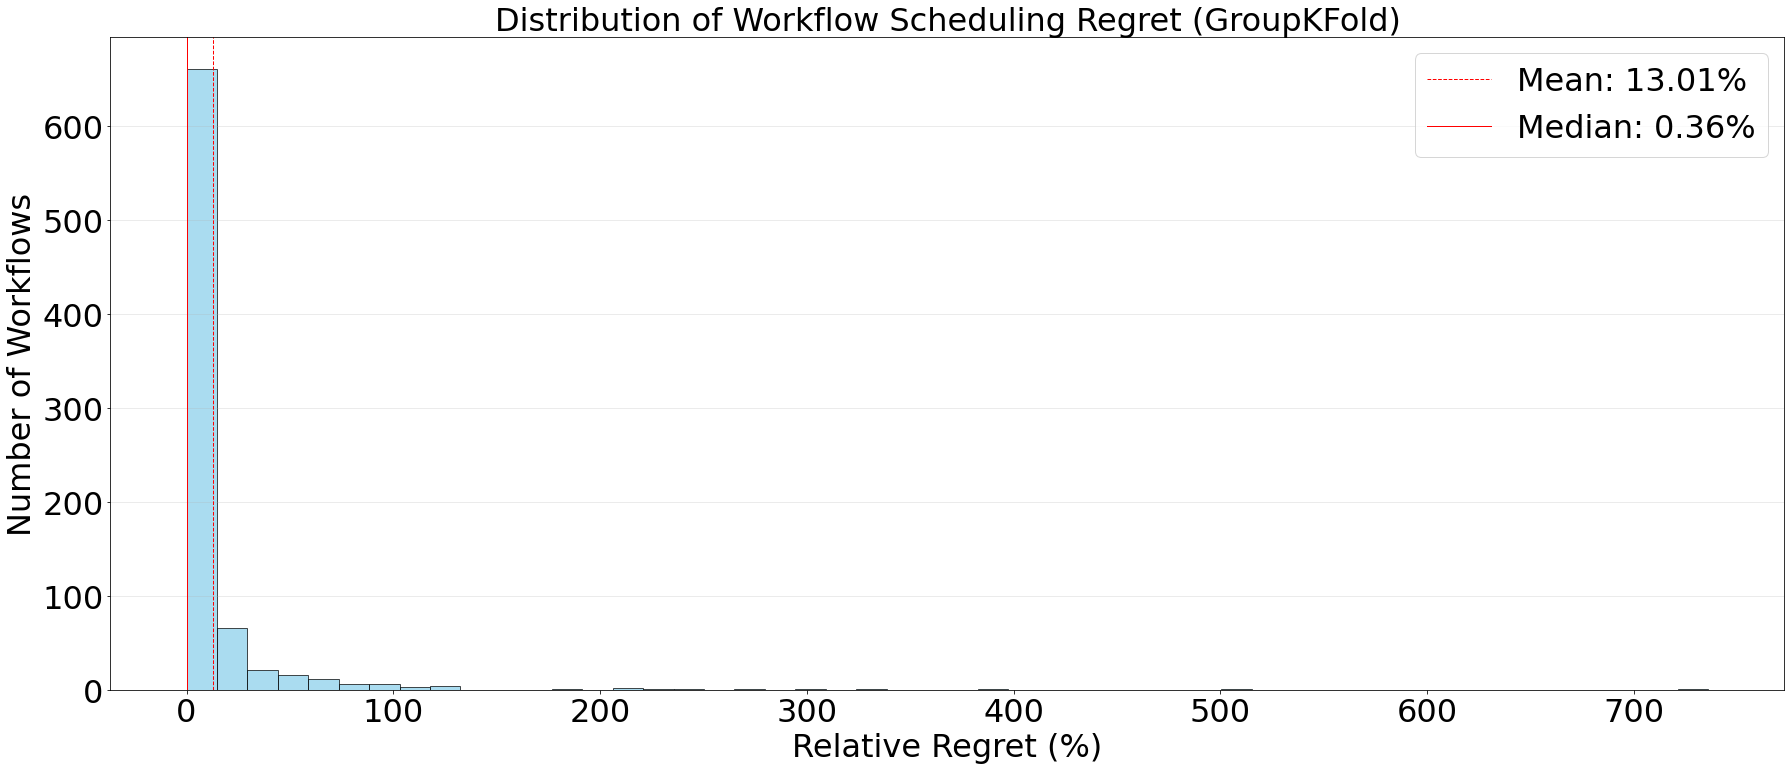

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert regret to percentages for easier reading
regret_pct = global_regret * 100

# Create the plot
plt.figure(figsize=(30, 12))
plt.hist(regret_pct, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of Workflow Scheduling Regret (GroupKFold)', fontsize=32)
plt.xlabel('Relative Regret (%)', fontsize=32)
plt.ylabel('Number of Workflows', fontsize=32)

plt.yticks(fontsize=32)
plt.xticks(fontsize=32)


# Add a vertical line for the mean
median_val = np.median(regret_pct)
plt.axvline(regret_pct.mean(), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {regret_pct.mean():.2f}%')
plt.axvline(median_val, color='red', linestyle='solid', linewidth=1, label=f'Median: {median_val:.2f}%')
plt.legend(fontsize=32, title_fontsize=32)

plt.grid(axis='y', alpha=0.3)
plt.show()



In [30]:
# Create a results table
outlier_analysis = pd.DataFrame({
    'wf_name': df_master.loc[all_test_indices, 'wf_name'].values,
    'regret_pct': np.array(fold_results) * 100,
    'true_best_alg': [alg_columns[i] for i in all_true_bests],
    'ai_picked_alg': [alg_columns[i] for i in all_ai_choices]
})

# Add the important features to see the context
for feat in ['maxIndSetR', 'hubScore', 'cpRat']:
    outlier_analysis[feat] = df_master.loc[all_test_indices, feat].values

# Sort by highest regret and show top 10
outliers = outlier_analysis.sort_values(by='regret_pct', ascending=False).head(20)

print("--- TOP 10 REGRET OUTLIERS ---")
print(outliers[['wf_name', 'regret_pct', 'true_best_alg', 'ai_picked_alg', 'hubScore', 'maxIndSetR']])

--- TOP 10 REGRET OUTLIERS ---
              wf_name  regret_pct true_best_alg ai_picked_alg  hubScore  \
761   atacseq_200.dot  736.071804       ms_2_A5       ms_1_A2  1.472750   
148           atacseq  512.210253       ms_1_A4       ms_1_A1  0.695122   
472  atacseq_1000.dot  384.281566       ms_2_A4       ms_2_A3  5.637320   
501  atacseq_1000.dot  331.070605       ms_2_A4       ms_2_A3  5.637320   
563     eager_200.dot  298.525381       ms_2_A2       ms_2_A3  1.458270   
592     eager_200.dot  279.292064       ms_1_A5       ms_2_A3  1.458270   
558     eager_200.dot  235.950329       ms_1_A4       ms_1_A3  1.458270   
555     eager_200.dot  234.559009       ms_1_A4       ms_1_A3  1.458270   
228             eager  214.678810       ms_1_A5       ms_1_A4  1.361680   
124           atacseq  212.443471       ms_1_A5       ms_1_A1  0.695122   
487         methylseq  177.146500       ms_1_A5       ms_2_A2  0.670782   
493         methylseq  130.962593       ms_1_A3       ms_1_A4  0.6707

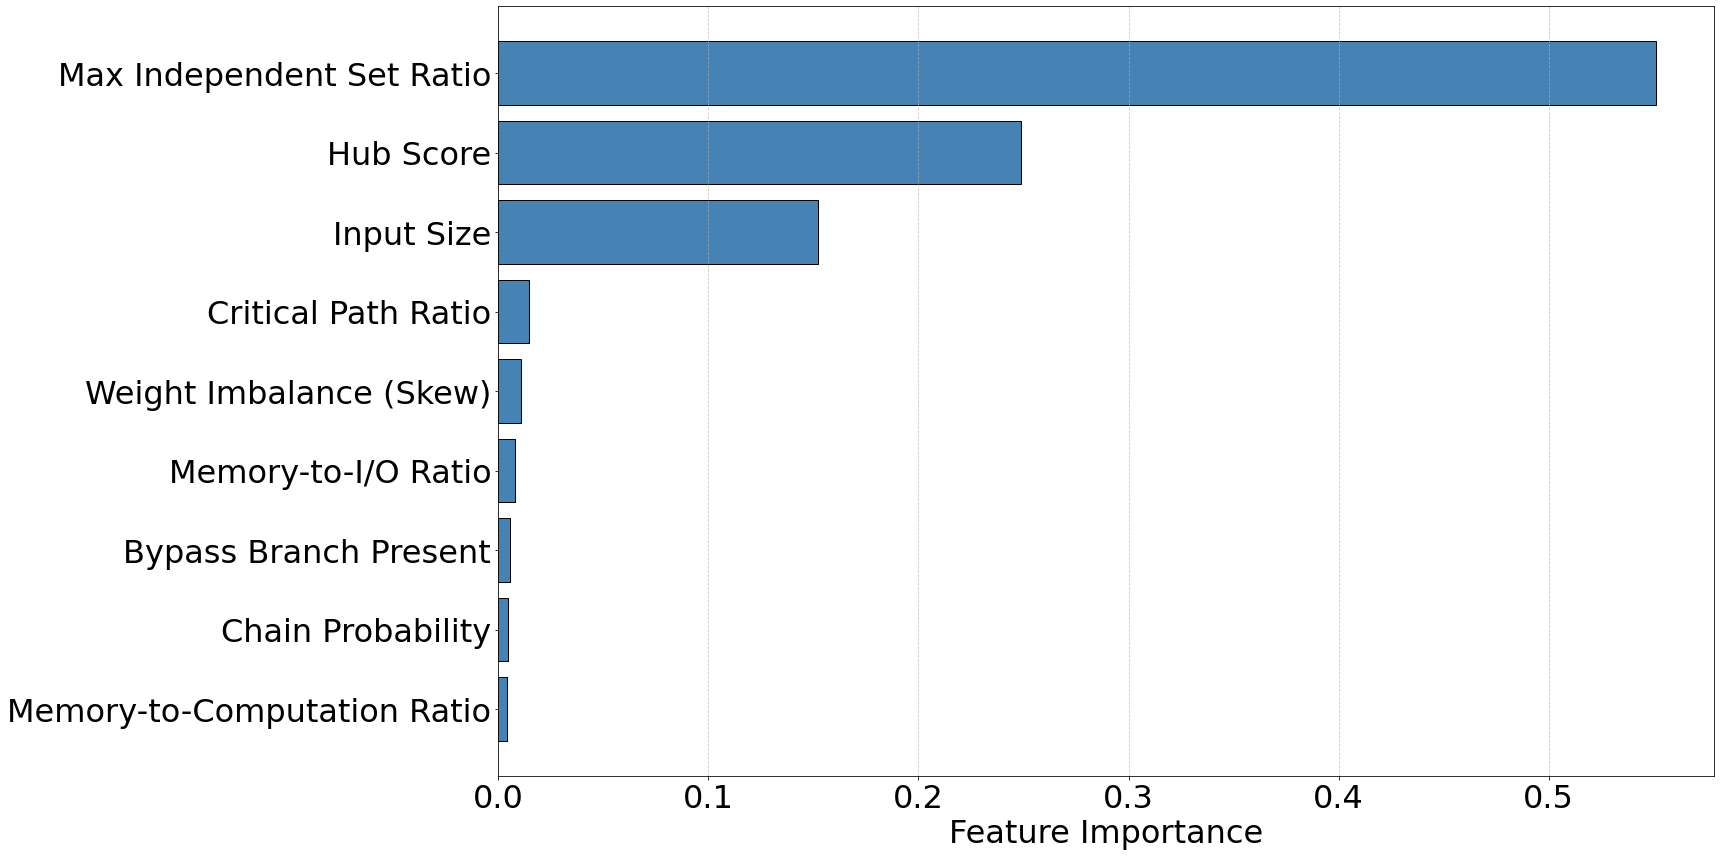

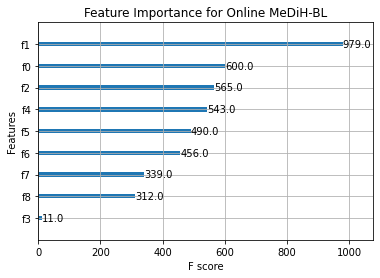

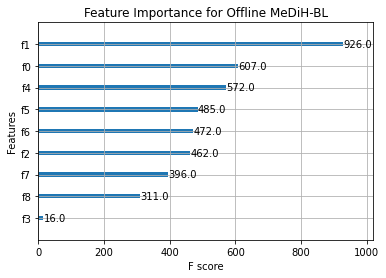

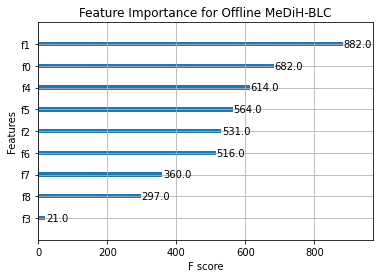

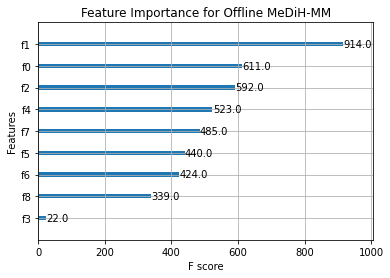

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Your Label Map (Fixed a couple of typos: ';' to ':' and 'rati' to 'ratio')
label_map = {
    "inp_size": "Input Size", 
    "chainProb": "Chain Probability",
    "hubScore": "Hub Score", 
    "bypBra": "Bypass Branch Present",
    "maxIndSetR": "Max Independent Set Ratio", 
    "cpRat": "Critical Path Ratio", 
    "wSkew": "Weight Imbalance (Skew)",
    "memToComp": "Memory-to-Computation Ratio", 
    "memToIo": "Memory-to-I/O Ratio",
    "deviations": "Data Deviations",
    "imbalance_pressure": "Imbalance Pressure (Interaction)",
    "memory_bottleneck": "Memory Bottleneck (Interaction)"
}

# 2. Collect average importance
all_importances = np.array([est.feature_importances_ for est in model.estimators_])
avg_importance = all_importances.mean(axis=0)

# 3. Get sorted feature names
raw_feature_names = np.array(X_transformed.columns)
sorted_idx = np.argsort(avg_importance)

# 4. Map the raw names to pretty names for the Y-axis
# We use .get(name, name) so it defaults to the raw name if it's missing from the map
sorted_pretty_labels = [label_map.get(raw_feature_names[i], raw_feature_names[i]) for i in sorted_idx]

# 5. Plotting
plt.figure(figsize=(24, 12))
plt.barh(sorted_pretty_labels, avg_importance[sorted_idx], color='steelblue', edgecolor='black')

plt.xlabel("Feature Importance", fontsize=32)
#plt.title("Which Graph Properties Matter Most for MeDiH?", fontsize=40)
plt.yticks(fontsize=32)
plt.xticks(fontsize=32)

# Add gridlines for readability
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

xgb.plot_importance(model.estimators_[0], title="Feature Importance for Online MeDiH-BL")
plt.show()


xgb.plot_importance(model.estimators_[1], title="Feature Importance for Offline MeDiH-BL")
plt.show()

xgb.plot_importance(model.estimators_[3], title="Feature Importance for Offline MeDiH-BLC")
plt.show()

xgb.plot_importance(model.estimators_[5], title="Feature Importance for Offline MeDiH-MM")
plt.show()

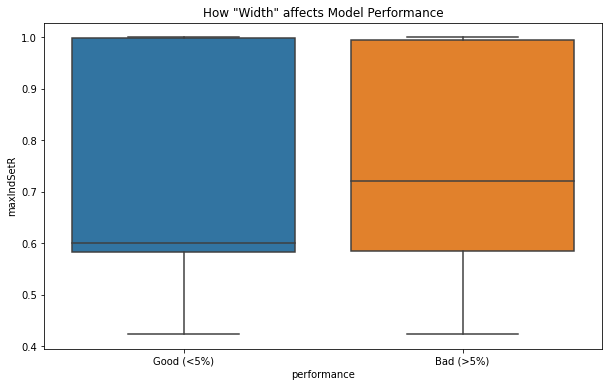

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dataframe for analysis
analysis_df = X_test.copy()
analysis_df['regret'] = regret  # From your previous calculation

# Categorize regret for visualization
analysis_df['performance'] = pd.cut(analysis_df['regret'], 
                                   bins=[-1, 0.05, 100], 
                                   labels=['Good (<5%)', 'Bad (>5%)'])

# Plotting the #1 feature
plt.figure(figsize=(10, 6))
sns.boxplot(x='performance', y='maxIndSetR', data=analysis_df)
plt.title('How "Width" affects Model Performance')
plt.show()